# SR.1 -- The International Standard Atmosphere (ISA)

The **International Standard Atmosphere** is an idealised, time-averaged model of how
atmospheric properties vary with altitude. It is defined in the *U.S. Standard
Atmosphere, 1976* {cite}`usatm1976` and adopted universally as the reference
condition for aircraft performance analysis, engine rating, altimeter calibration,
and aerodynamic design. It is consistent with ICAO Doc 7488.

Every performance figure in a type certificate -- rate of climb, ceiling, range,
takeoff field length -- is computed at ISA conditions unless explicitly qualified
otherwise. An aircraft that meets its performance guarantees "at ISA" must separately
demonstrate hot-day and cold-day margins.

## Governing equations

The ISA is built on two physical laws applied layer by layer.

**Hydrostatic equation** -- pressure decreases with altitude in proportion to the
weight of the air column above:

$$\frac{dP}{dh} = -\rho g$$

**Ideal gas law** -- relates pressure, density, and temperature:

$$P = \rho R T \qquad R_{\text{air}} = 287.058 \ \text{J kg}^{-1}\text{K}^{-1}$$

Combining these with a constant **temperature lapse rate** $L$ gives the
**tropospheric pressure law**:

$$\frac{P}{P_0} = \left(\frac{T}{T_0}\right)^{-g/(LR)}$$

where the exponent evaluates to $-g/(LR) \approx 5.2561$ {cite}`usatm1976`.

In the **isothermal stratosphere** (above the tropopause at 11 000 m) the lapse rate
is zero and the equation reduces to an exponential decay:

$$P = P_{11} \exp\!\left(-\frac{g(h - 11000)}{R\,T_{11}}\right)$$

Dynamic viscosity is computed via **Sutherland's law** {cite}`usatm1976`:

$$\mu = \mu_{\text{ref}} \left(\frac{T}{T_{\text{ref}}}\right)^{3/2}
       \frac{T_{\text{ref}} + S}{T + S}
\qquad \mu_{\text{ref}} = 1.716 \times 10^{-5}\ \text{Pa s},\quad S = 110.4\ \text{K}$$

## Layer structure (U.S. Standard Atmosphere 1976)

| Layer | Altitude range | Lapse rate |
|---|---|---|
| Troposphere | 0 -- 11 000 m (0 -- 36 089 ft) | -6.5 K / km |
| Tropopause / lower stratosphere | 11 000 -- 20 000 m | 0 K / km (isothermal) |
| Middle stratosphere | 20 000 -- 32 000 m | +1.0 K / km |

This notebook covers the first two layers, which encompass all subsonic commercial
and general aviation flight and most military fixed-wing operations.

In [1]:
import numpy as np
import pandas as pd

# ── ISA constants (U.S. Standard Atmosphere 1976) ─────────────────────────────
T0    = 288.15       # Sea-level temperature, K
P0    = 101_325.0    # Sea-level pressure, Pa
rho0  = 1.225        # Sea-level density, kg/m^3
g     = 9.80665      # Gravitational acceleration, m/s^2
R     = 287.058      # Specific gas constant for dry air, J/(kg K)
gamma = 1.4          # Ratio of specific heats
L     = -0.0065      # Troposphere lapse rate, K/m

# Tropopause transition values at 11 000 m
h_tp   = 11_000.0
T_tp   = T0 + L * h_tp                          # 216.65 K
P_tp   = P0  * (T_tp / T0) ** (-g / (L * R))
rho_tp = rho0 * (T_tp / T0) ** (-g / (L * R) - 1)

# Sutherland viscosity constants
mu_ref = 1.716e-5   # Pa s at T_ref
T_ref  = 273.15     # K
S      = 110.4      # K


def isa(h_m):
    """
    Compute ISA properties at geometric altitude h_m (metres).
    Valid for 0 to 20 000 m. Returns dict: T, P, rho, a, mu, nu, sigma.
    """
    h = float(h_m)
    if h <= h_tp:
        T   = T0  + L * h
        P   = P0   * (T / T0)  ** (-g / (L * R))
        rho = rho0 * (T / T0)  ** (-g / (L * R) - 1)
    else:
        T   = T_tp
        P   = P_tp   * np.exp(-g * (h - h_tp) / (R * T_tp))
        rho = rho_tp * np.exp(-g * (h - h_tp) / (R * T_tp))

    a     = np.sqrt(gamma * R * T)
    mu    = mu_ref * (T / T_ref)**1.5 * (T_ref + S) / (T + S)
    nu    = mu / rho
    sigma = rho / rho0

    return dict(T=T, P=P, rho=rho, a=a, mu=mu, nu=nu, sigma=sigma)


# Sanity check at sea level
sl = isa(0)
print(f"Sea-level check:")
print(f"  T   = {sl['T']:.2f} K  ({sl['T']-273.15:.2f} C)   [target 288.15 K]")
print(f"  P   = {sl['P']:.1f} Pa              [target 101325 Pa]")
print(f"  rho = {sl['rho']:.4f} kg/m^3         [target 1.2250]")
print(f"  a   = {sl['a']:.2f} m/s             [target 340.29]")

Sea-level check:
  T   = 288.15 K  (15.00 C)   [target 288.15 K]
  P   = 101325.0 Pa              [target 101325 Pa]
  rho = 1.2250 kg/m^3         [target 1.2250]
  a   = 340.30 m/s             [target 340.29]


In [2]:
# ISA table in mixed units -- every 1 000 ft from 0 to 65 000 ft
ft_to_m = 0.3048
rows = []
for h_ft in range(0, 66_000, 1_000):
    h_m = h_ft * ft_to_m
    p   = isa(h_m)
    rows.append({
        "Alt (ft)"   : h_ft,
        "Alt (m)"    : round(h_m),
        "T (K)"      : round(p["T"], 2),
        "T (C)"      : round(p["T"] - 273.15, 2),
        "P (Pa)"     : round(p["P"], 1),
        "P (hPa)"    : round(p["P"] / 100, 3),
        "rho (kg/m3)": round(p["rho"], 5),
        "sigma"      : round(p["sigma"], 5),
        "a (m/s)"    : round(p["a"], 2),
        "a (kt)"     : round(p["a"] / 0.514444, 1),
        "mu (Pa.s)"  : f'{p["mu"]:.4e}',
        "nu (m2/s)"  : f'{p["nu"]:.4e}',
    })

df = pd.DataFrame(rows)

# Display every 2 000 ft
disp = df[df["Alt (ft)"] % 2_000 == 0].reset_index(drop=True)
pd.set_option("display.max_rows", 40)
print(disp.to_string(index=False))

 Alt (ft)  Alt (m)  T (K)  T (C)   P (Pa)  P (hPa)  rho (kg/m3)   sigma  a (m/s)  a (kt)  mu (Pa.s)  nu (m2/s)
        0        0 288.15  15.00 101325.0 1013.250      1.22500 1.00000   340.30   661.5 1.7893e-05 1.4607e-05
     2000      610 284.19  11.04  94213.0  942.130      1.15490 0.94277   337.95   656.9 1.7701e-05 1.5327e-05
     4000     1219 280.23   7.08  87510.8  875.108      1.08791 0.88809   335.58   652.3 1.7508e-05 1.6093e-05
     6000     1829 276.26   3.11  81199.9  811.999      1.02393 0.83586   333.20   647.7 1.7314e-05 1.6909e-05
     8000     2438 272.30  -0.85  75262.8  752.628      0.96288 0.78602   330.81   643.0 1.7118e-05 1.7778e-05
    10000     3048 268.34  -4.81  69682.1  696.821      0.90464 0.73848   328.39   638.3 1.6921e-05 1.8704e-05
    12000     3658 264.38  -8.77  64441.4  644.414      0.84914 0.69318   325.96   633.6 1.6722e-05 1.9693e-05
    14000     4267 260.41 -12.74  59524.4  595.244      0.79629 0.65003   323.50   628.8 1.6523e-05 2.0749e-05
 

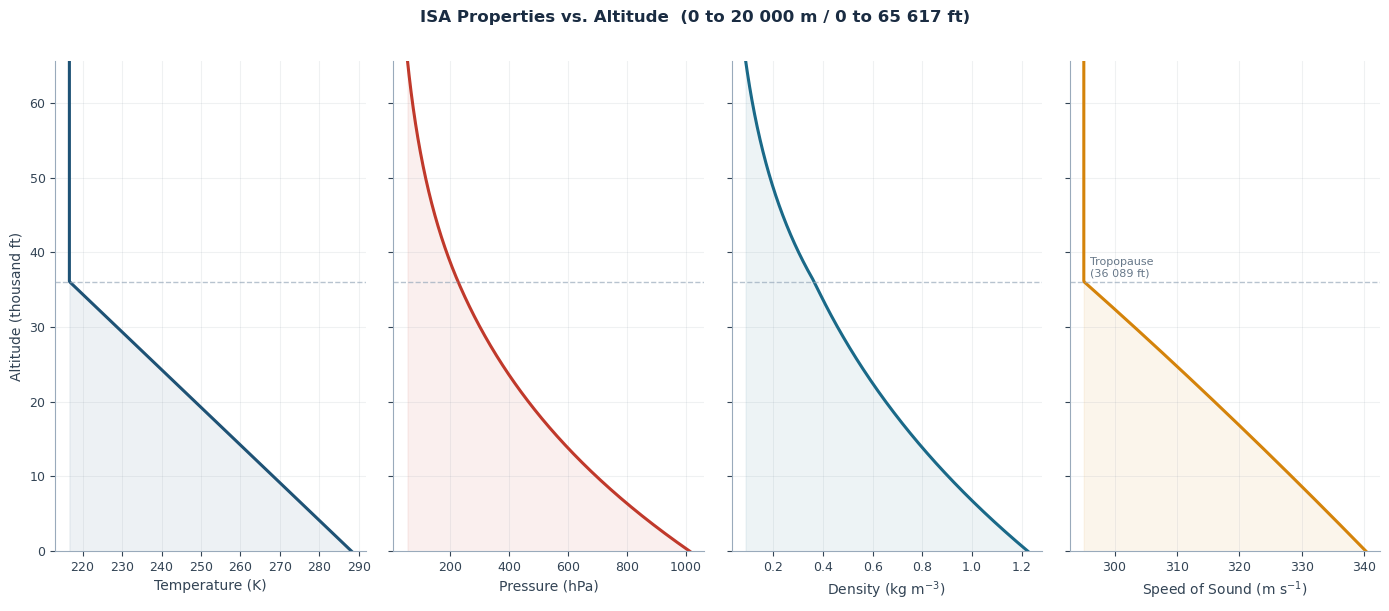

In [3]:
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor':      'none',
    'axes.facecolor':        'none',
    'savefig.facecolor':     'none',
    'savefig.transparent':   True,
    'axes.edgecolor':        '#888888',
    'axes.labelcolor':       '#cccccc',
    'text.color':            '#cccccc',
    'xtick.color':           '#cccccc',
    'ytick.color':           '#cccccc',
    'grid.color':            '#555555',
    'font.size':             11,
    'axes.titlesize':        13,
    'axes.labelsize':        11,
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       10,
    'legend.title_fontsize': 10,
    'figure.titlesize':      13,
    'lines.linewidth':       2.0,
})
# Okabe-Ito colorblind-safe palette
OKI = ["#0072B2", "#D55E00", "#009E73", "#E69F00",
       "#56B4E9", "#CC79A7", "#F0E442", "#333333"]
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

h_range = np.linspace(0, 20_000, 500)
h_ft    = h_range / 0.3048 / 1000

T_arr   = np.array([isa(h)["T"]   for h in h_range])
P_arr   = np.array([isa(h)["P"]   for h in h_range]) / 100
rho_arr = np.array([isa(h)["rho"] for h in h_range])
a_arr   = np.array([isa(h)["a"]   for h in h_range])

panel_colors = [OKI[0], OKI[1], OKI[2], OKI[3]]   # blue, vermilion, green, amber
fig, axes = plt.subplots(1, 4, figsize=(14, 6), sharey=True)

panels = [
    (axes[0], T_arr,   "Temperature (K)",             panel_colors[0]),
    (axes[1], P_arr,   "Pressure (hPa)",               panel_colors[1]),
    (axes[2], rho_arr, r"Density (kg m$^{-3}$)",       panel_colors[2]),
    (axes[3], a_arr,   r"Speed of Sound (m s$^{-1}$)", panel_colors[3]),
]
tp_kft = h_tp / 0.3048 / 1000

for ax, data, xlabel, color in panels:
    ax.plot(data, h_ft, color=color, lw=2.2)
    ax.fill_betweenx(h_ft, data, data.min(), alpha=0.10, color=color)
    ax.axhline(tp_kft, color="#aaaaaa", lw=1.0, linestyle="--")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.grid(True, linestyle="-", alpha=0.15)
    ax.yaxis.grid(True, linestyle="-", alpha=0.15)

axes[0].set_ylabel("Altitude (thousand ft)", fontsize=11)
axes[0].set_ylim(0, h_ft.max())
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(10))
axes[3].text(a_arr[-1] + 1, tp_kft + 0.4,
             "Tropopause\n(36 089 ft)", fontsize=10, color="#555555", va="bottom")

fig.suptitle("ISA Properties vs. Altitude  (0 to 20 000 m / 0 to 65 617 ft)",
             fontsize=13, fontweight="semibold", y=1.01)
plt.tight_layout()
plt.show()


## Density Altitude

**Pressure altitude** is the altitude in the ISA at which the ambient pressure equals
the measured static pressure. It is what the altimeter reads when set to 1013.25 hPa
(29.92 inHg).

**Density altitude** is the altitude in the ISA at which the ISA density equals the
actual ambient density. It governs aerodynamic and propulsive performance -- a higher
density altitude means lower lift, reduced engine thrust, and degraded climb
performance, regardless of the geometric altitude {cite}`usatm1976`.

Given an actual temperature $T_{\text{act}}$ and actual pressure $P_{\text{act}}$:

$$\rho_{\text{act}} = \frac{P_{\text{act}}}{R\,T_{\text{act}}}$$

The density altitude $h_\rho$ is then found by inverting the ISA $\rho(h)$ curve:

$$h_\rho = h \;\text{ such that }\; \rho_{\text{ISA}}(h) = \rho_{\text{act}}$$

The approximate formula (valid in the troposphere) is:

$$h_\rho \approx h_p + \frac{T_{\text{ISA}}(h_p) - T_{\text{act}}}{|L|}$$

where $h_p$ is the pressure altitude and $L = -6.5$ K/km is the lapse rate.

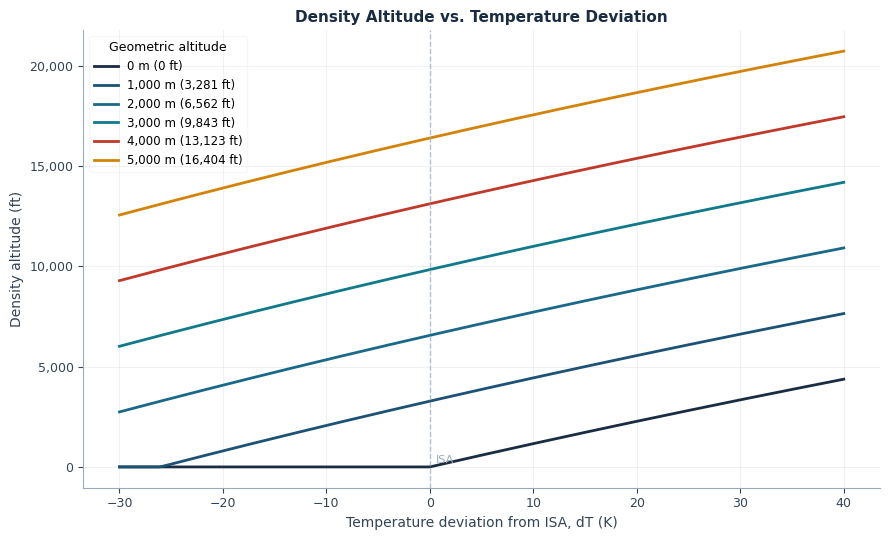

In [4]:
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor':      'none',
    'axes.facecolor':        'none',
    'savefig.facecolor':     'none',
    'savefig.transparent':   True,
    'axes.edgecolor':        '#888888',
    'axes.labelcolor':       '#cccccc',
    'text.color':            '#cccccc',
    'xtick.color':           '#cccccc',
    'ytick.color':           '#cccccc',
    'grid.color':            '#555555',
    'font.size':             11,
    'axes.titlesize':        13,
    'axes.labelsize':        11,
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       10,
    'legend.title_fontsize': 10,
    'figure.titlesize':      13,
    'lines.linewidth':       2.0,
})
# Okabe-Ito colorblind-safe palette
OKI = ["#0072B2", "#D55E00", "#009E73", "#E69F00",
       "#56B4E9", "#CC79A7", "#F0E442", "#333333"]
from scipy.optimize import brentq
import matplotlib.ticker as ticker

def density_altitude(h_geom_m, delta_T=0.0):
    """Density altitude (m) for a given geometric altitude and ISA delta-T (K)."""
    p          = isa(h_geom_m)
    T_actual   = p["T"] + delta_T
    rho_actual = p["P"] / (R * T_actual)
    if rho_actual >= rho0:
        return 0.0
    try:
        h_da = brentq(lambda h: isa(h)["rho"] - rho_actual, 0, 20_000)
    except ValueError:
        h_da = 20_000.0
    return h_da

fig, ax = plt.subplots(figsize=(9, 5.5))

delta_T_range = np.linspace(-30, 40, 200)
alt_cases     = [0, 1000, 2000, 3000, 4000, 5000]
# Use first 6 OKI colors
da_colors     = OKI[:6]

for h_geom, col in zip(alt_cases, da_colors):
    da_ft = [density_altitude(h_geom, dT) / 0.3048 for dT in delta_T_range]
    lbl   = f"{h_geom:,} m ({h_geom/0.3048:,.0f} ft)"
    ax.plot(delta_T_range, da_ft, color=col, lw=2.0, label=lbl)

ax.axvline(0, color="#aaaaaa", lw=1.0, linestyle="--")
ax.text(0.6, 200, "ISA", fontsize=10, color="#888888")
ax.set_xlabel("Temperature deviation from ISA, dT (K)", fontsize=11)
ax.set_ylabel("Density altitude (ft)", fontsize=11)
ax.set_title("Density Altitude vs. Temperature Deviation", fontsize=13, fontweight="semibold")
ax.legend(title="Geometric altitude", fontsize=10, title_fontsize=10,
          loc="upper left", framealpha=0.85)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="-", alpha=0.2)
ax.tick_params(labelsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.tight_layout()
plt.show()


## Non-Standard Atmospheres

Real conditions deviate from ISA. The principal variants used in aircraft performance
analysis are:

**ISA +15 (hot day)** -- $T = T_{\text{ISA}} + 15$ K at all altitudes. Used for
worst-case performance: maximum density altitude, maximum fuel consumption, lowest
engine thrust margin. Required by most civil airworthiness codes for climb certification.

**ISA -15 (cold day)** -- $T = T_{\text{ISA}} - 15$ K. Gives higher density and higher
engine thrust, but higher structural loads from dynamic pressure at low altitude and
lower true airspeed for a given Mach number in cold conditions.

**MIL-HDBK-310 hot and cold day** -- more conservative military extremes, often
ISA +35 at sea level for hot desert operations or ISA -55 for Arctic cold-soak.
Required for military aircraft qualification.

**Tropical** and **Arctic** standard atmospheres (ICAO Doc 7488) {cite}`usatm1976` --
regional profiles based on measured climatological data, used when specific theatre
performance guarantees are required.

For design purposes:

- Use **ISA** for all baseline performance bookkeeping and comparison
- Verify minimum climb margins at **ISA +15** (or higher per applicable specification)
- Check structural loads and handling qualities at the applicable **cold-day** limit

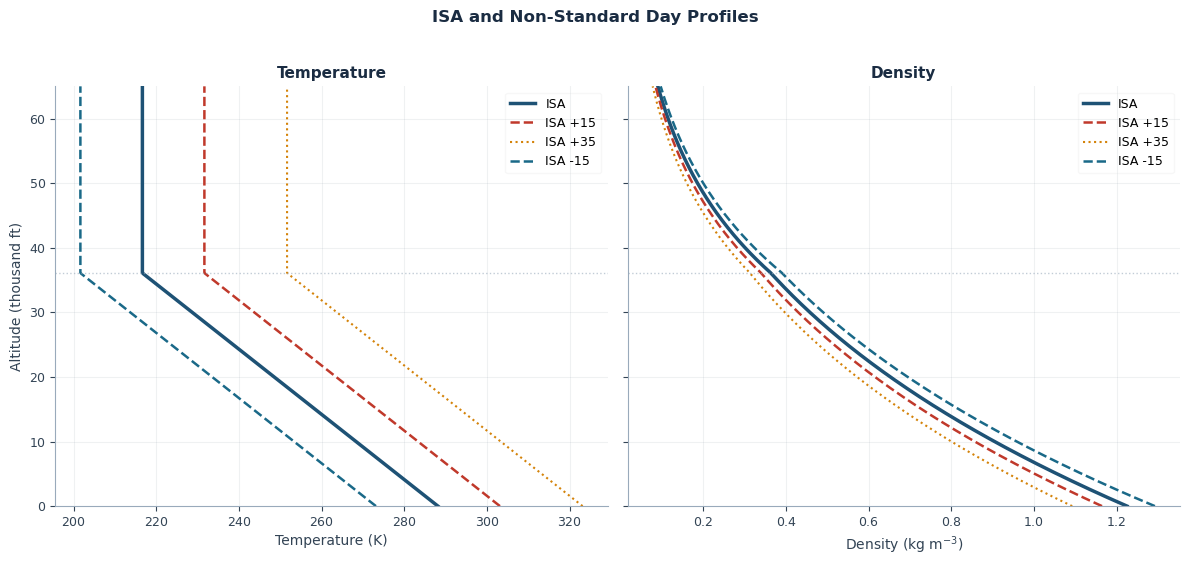

In [5]:
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor':      'none',
    'axes.facecolor':        'none',
    'savefig.facecolor':     'none',
    'savefig.transparent':   True,
    'axes.edgecolor':        '#888888',
    'axes.labelcolor':       '#cccccc',
    'text.color':            '#cccccc',
    'xtick.color':           '#cccccc',
    'ytick.color':           '#cccccc',
    'grid.color':            '#555555',
    'font.size':             11,
    'axes.titlesize':        13,
    'axes.labelsize':        11,
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       10,
    'legend.title_fontsize': 10,
    'figure.titlesize':      13,
    'lines.linewidth':       2.0,
})
# Okabe-Ito colorblind-safe palette
OKI = ["#0072B2", "#D55E00", "#009E73", "#E69F00",
       "#56B4E9", "#CC79A7", "#F0E442", "#333333"]
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

h_range_ft = np.linspace(0, 65_000, 400)
h_range_m  = h_range_ft * 0.3048

variants = [
    ("ISA",      0,   OKI[0], 2.5, "-"),
    ("ISA +15", 15,   OKI[1], 1.8, "--"),
    ("ISA +35", 35,   OKI[3], 1.5, ":"),
    ("ISA -15", -15,  OKI[2], 1.8, "--"),
]

for ax, prop, ylabel, title_str in [
    (axes[0], "T",   "Temperature (K)",        "Temperature"),
    (axes[1], "rho", r"Density (kg m$^{-3}$)", "Density"),
]:
    for label, dT, col, lw, ls in variants:
        vals = []
        for h_m in h_range_m:
            p     = isa(h_m)
            T_act = p["T"] + dT
            vals.append(T_act if prop == "T" else p["P"] / (R * T_act))
        ax.plot(vals, h_range_ft / 1000, color=col, lw=lw, linestyle=ls, label=label)
    ax.axhline(36.089, color="#aaaaaa", lw=1.0, linestyle=":", alpha=0.8)
    ax.set_xlabel(ylabel, fontsize=11)
    ax.set_title(title_str, fontsize=13, fontweight="semibold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="-", alpha=0.2)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=10, framealpha=0.85)

axes[0].set_ylabel("Altitude (thousand ft)", fontsize=11)
axes[0].set_ylim(0, 65)
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(10))

fig.suptitle("ISA and Non-Standard Day Profiles", fontsize=13,
             fontweight="semibold", y=1.02)
plt.tight_layout()
plt.show()


## Primary Reference

The complete tabulated data for the U.S. Standard Atmosphere -- temperature, pressure,
density, speed of sound, dynamic and kinematic viscosity, thermal conductivity, and
mean free path from -5 km to 1 000 km altitude -- is published in {cite}`usatm1976`.

The Python implementation above reproduces Tables 1 through 4 of that document
(0 to 86 km geometric altitude) for the troposphere and lower stratosphere.
Computed values agree with the published tables to within rounding error.

```{bibliography}
:filter: docname in docnames
```